In [7]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm
from mpl_toolkits.mplot3d import Axes3D
from abc import ABC, abstractmethod
import math
import re
from scipy.optimize import minimize
from itertools import product
import seaborn as sns
from matplotlib import animation
%pip install numba-cuda
import numba as nb
from numba import cuda
%pip install cupy-cuda12x
import cupy as cp

# Apply Periodic Boundary Conditions

In [8]:
def apply_pbc(position, box_size):
    return position % box_size

# Initialize Positions and Velocities

In [9]:
@nb.njit
def apply_pbc(pos: np.ndarray | cp.ndarray | float, box_size: float) -> np.ndarray | cp.ndarray:
    """
    Wraps the chain inside the unit cell
    """
    return pos % box_size

@nb.njit
def assign_position(positions, new_positions, idx):
    positions[0, idx] = new_positions[0]
    positions[1, idx] = new_positions[1]
    positions[2, idx] = new_positions[2]

@nb.njit
def initialize_chain_numba(
    n_particles: int,
    box_size: float,
    r0: float,
    rng: np.random._generator.Generator,
    dtype=np.float32
) -> np.ndarray:
    """
    Randomly initialize atom positions by growing the chain
    """
    positions = np.zeros((3, n_particles), dtype=dtype)

    current_position = np.array([box_size / 2, box_size / 2, box_size / 2], dtype=dtype)
    assign_position(positions, current_position, 0)

    for i in range(1, n_particles):
        direction = rng.normal(size = 3).astype(dtype)
        norm = np.sqrt(direction[0]**2 + direction[1]**2 + direction[2]**2)
        direction /= norm

        next_position = current_position + r0 * direction
        next_position = apply_pbc(next_position, box_size).astype(dtype)
        assign_position(positions, next_position, i)
        current_position = next_position

    return positions

def initialize_velocities_cupy(
    n_particles: int,
    target_temperature: float, 
    mass: float,
    rng: cp.random._generator_api.Generator,
    kB=1.0,
    dtype=cp.float32
) -> cp.ndarray:
    """
    Initialize particle velocities by drawing from the Maxwell-Botzmann distribution at target temperature
    """
    sigma = cp.sqrt(kB * target_temperature / mass).astype(dtype)

    velocities = rng.standard_normal(
        size=(3, n_particles), 
        dtype=dtype
    )
    velocities = velocities * sigma

    # Remove center-of-mass velocity
    velocities -= cp.mean(velocities, axis=-1).reshape(3, 1)

    return velocities

In [10]:
# qc
rng_np = np.random.default_rng(42)
pos = initialize_chain_numba(10, 20.0, 1.0, rng_np)
rng_cp = cp.random.default_rng(42)
v = initialize_velocities_cupy(1000, target_temperature=1.0, mass=1.0, rng = rng_cp)
v

array([[-0.95401406, -0.22627392, -0.7407161 , ...,  0.61938095,
        -0.38514563,  1.0126818 ],
       [ 0.71394455,  1.9269174 , -0.1572528 , ...,  0.41389567,
         3.342068  ,  0.21708886],
       [-0.1798589 ,  0.09168955, -0.7073451 , ..., -0.524985  ,
        -0.01233297,  0.936227  ]], dtype=float32)

# Compute Forces

## Harmonic Forces

In [19]:
@nb.njit
def minimum_image(displacement, box_size):
    """
    Apply minimum image convention to a 3D displacement vector.
    """
    out = np.empty(3, dtype=displacement.dtype)
    for d in range(3):
        out[d] = displacement[d] - box_size * np.round(displacement[d] / box_size)
    return out

@nb.njit
def compute_harmonic_forces(positions, k, r0, box_size):
    """
    Compute harmonic bond forces for a linear chain.

    Parameters
    ----------
    positions : array, shape (n_particles, 3)
        Particle positions.
    k : float
        Harmonic spring constant.
    r0 : float
        Equilibrium bond length.
    box_size : float
        Periodic box length.

    Returns
    -------
    forces : array, shape (n_particles, 3)
        Force on each particle.
    """
    n_particles = positions.shape[0]
    forces = np.zeros_like(positions)

    for i in range(n_particles - 1):
        displacement = np.empty(3, dtype=positions.dtype)
        for d in range(3):
            displacement[d] = positions[i + 1, d] - positions[i, d]

        displacement = minimum_image(displacement, box_size)

        distance_sq = 0.0
        for d in range(3):
            distance_sq += displacement[d] * displacement[d]
        distance = np.sqrt(distance_sq)

        if distance > 0.0:
            force_magnitude = -k * (distance - r0)

            for d in range(3):
                force_component = force_magnitude * displacement[d] / distance
                forces[i, d] -= force_component
                forces[i + 1, d] += force_component

    return forces


In [24]:
@cuda.jit(device=True)
def minimum_image_1d(dx, box_size):
    half = 0.5 * box_size
    if dx > half:
        dx -= box_size
    elif dx < -half:
        dx += box_size
    return dx

@cuda.jit
def compute_bond_forces_kernel(positions, bond_forces, k, r0, box_size, n_particles):
    sh_pos = cuda.shared.array(shape=(129, 3), dtype=nb.float32)

    tid = cuda.threadIdx.x
    bid = cuda.blockIdx.x
    bdim = cuda.blockDim.x

    i = bid * bdim + tid      # global bond index
    p = bid * bdim + tid      # global particle index to load

    # Load one particle per thread
    if p < n_particles:
        sh_pos[tid, 0] = positions[p, 0]
        sh_pos[tid, 1] = positions[p, 1]
        sh_pos[tid, 2] = positions[p, 2]

    # Last thread loads the extra halo particle
    if tid == bdim - 1:
        p_extra = p + 1
        if p_extra < n_particles:
            sh_pos[tid + 1, 0] = positions[p_extra, 0]
            sh_pos[tid + 1, 1] = positions[p_extra, 1]
            sh_pos[tid + 1, 2] = positions[p_extra, 2]

    cuda.syncthreads()

    if i < n_particles - 1:
        dx = sh_pos[tid + 1, 0] - sh_pos[tid, 0]
        dy = sh_pos[tid + 1, 1] - sh_pos[tid, 1]
        dz = sh_pos[tid + 1, 2] - sh_pos[tid, 2]

        dx = minimum_image_1d(dx, box_size)
        dy = minimum_image_1d(dy, box_size)
        dz = minimum_image_1d(dz, box_size)

        dist = math.sqrt(dx * dx + dy * dy + dz * dz)

        if dist > 0.0:
            force_mag = -k * (dist - r0)
            inv_dist = 1.0 / dist
            bond_forces[i, 0] = force_mag * dx * inv_dist
            bond_forces[i, 1] = force_mag * dy * inv_dist
            bond_forces[i, 2] = force_mag * dz * inv_dist
        else:
            bond_forces[i, 0] = 0.0
            bond_forces[i, 1] = 0.0
            bond_forces[i, 2] = 0.0

@cuda.jit
def assemble_forces_kernel(bond_forces, forces, n_particles):
    p = cuda.grid(1)

    if p < n_particles:
        fx = 0.0
        fy = 0.0
        fz = 0.0

        # left bond contributes positively
        if p > 0:
            fx += bond_forces[p - 1, 0]
            fy += bond_forces[p - 1, 1]
            fz += bond_forces[p - 1, 2]

        # right bond contributes negatively
        if p < n_particles - 1:
            fx -= bond_forces[p, 0]
            fy -= bond_forces[p, 1]
            fz -= bond_forces[p, 2]

        forces[p, 0] = fx
        forces[p, 1] = fy
        forces[p, 2] = fz

inf
nan
inf
inf
inf
nan
inf
inf
inf
nan
nan
inf
inf
935.62286
nan
inf
inf
920.6522
nan
inf
inf
nan
inf
inf
inf
nan
inf
inf
inf
nan


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 3 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 4 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


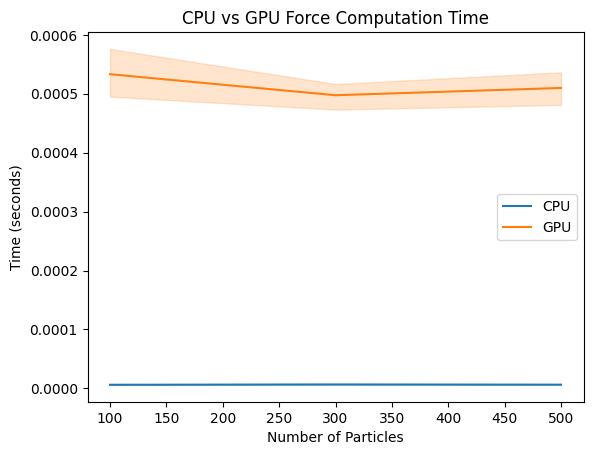

In [26]:
import time
import numpy as np
import pandas as pd
import cupy as cp
import matplotlib.pyplot as plt
import seaborn as sns
from numba import cuda

time_df = pd.DataFrame(columns=["n_particles", "cpu_time", "gpu_time"])

n_warmups = 3
n_trials = 10
sizes = [100, 300, 500]
TPB = 128

for n_particles in sizes:
    for i in range(n_warmups + n_trials):
        rng = np.random.default_rng(i)

        box_size = 20.0
        r0 = 1.0
        k = 100.0

        positions = np.asarray(
            initialize_chain_numba(n_particles, box_size, r0, rng),
            dtype=np.float32
        )

        positions_gpu = cp.asarray(positions, dtype=cp.float32)
        bond_forces_gpu = cp.zeros((n_particles - 1, 3), dtype=cp.float32)
        forces_gpu = cp.zeros((n_particles, 3), dtype=cp.float32)

        # CPU timing
        start = time.perf_counter()
        forces_cpu = compute_harmonic_forces(positions, k, r0, box_size)
        cpu_time = time.perf_counter() - start

        # GPU timing
        blocks_bonds = (n_particles - 1 + TPB - 1) // TPB
        blocks_particles = (n_particles + TPB - 1) // TPB

        start = time.perf_counter()
        compute_bond_forces_kernel[blocks_bonds, TPB](
            positions_gpu, bond_forces_gpu, k, r0, box_size, n_particles
        )
        assemble_forces_kernel[blocks_particles, TPB](
            bond_forces_gpu, forces_gpu, n_particles
        )
        cuda.synchronize()
        gpu_time = time.perf_counter() - start

        if i >= n_warmups:
            time_df.loc[len(time_df)] = [n_particles, cpu_time, gpu_time]
            forces_gpu_host = cp.asnumpy(forces_gpu)
            print(np.max(np.abs(forces_cpu - forces_gpu_host.T)))
            
sns.lineplot(data=time_df, x="n_particles", y="cpu_time", label="CPU")
sns.lineplot(data=time_df, x="n_particles", y="gpu_time", label="GPU")
plt.xlabel("Number of Particles")
plt.ylabel("Time (seconds)")
plt.title("CPU vs GPU Force Computation Time")
plt.legend()
plt.show()

## Lennard-Jones Forces

In [8]:
@nb.njit
def compute_lennard_jones_forces_njit(
    positions,
    n_particles,
    epsilon_repulsive,
    epsilon_attractive,
    sigma,
    box_size,
    cutoff
):
    forces = np.zeros_like(positions)

    cutoff_sq = cutoff * cutoff

    for i in range(n_particles):
        for j in range(i + 1, n_particles):
            sep = j - i

            if sep == 2:
                epsilon = epsilon_repulsive
            elif sep > 2:
                epsilon = epsilon_attractive
            else:
                continue

            displacement = np.empty(3, dtype=positions.dtype)
            for d in range(3):
                displacement[d] = positions[j, d] - positions[i, d]

            displacement = minimum_image(displacement, box_size)

            r2 = 0.0
            for d in range(3):
                r2 += displacement[d] * displacement[d]

            if r2 < cutoff_sq and r2 > 0.0:
                r = np.sqrt(r2)
                sr = sigma / r
                sr2 = sr * sr
                sr6 = sr2 * sr2 * sr2
                sr12 = sr6 * sr6

                force_magnitude = 24.0 * epsilon * (sr12 - 0.5 * sr6) / r

                for d in range(3):
                    force_component = force_magnitude * displacement[d] / r
                    forces[i, d] -= force_component
                    forces[j, d] += force_component

    return forces

# Velocity Verlet Integration

1. Position update
$$ r(t+\Delta t) = r(t) + v(t)\Delta t + \frac{F(t)}{2m} \Delta t^2 $$
2. Velocity update
$$ v(t+\Delta t) = v(t) + \frac{F(t) + F(t+\Delta t)}{2m} \Delta t $$

Naive implementation
```{python}
for step in range(t_steps):
  forces = compute_forces(positions)  # F(t)
  v += 0.5 * forces / mass * dt
  positions += v * dt
  wrap(positions)
  forces = compute_forces(positions)  # F(t + dt)
  v += 0.5 * forces / mass * dt
  if step % rescale_interval == 0:
    v = rescale(v)
```

Notice that F(t + dt, step i-1) = F(t, step i)
Optimized sequential version
```{python}
# first iteration
// launch v_update
forces = compute_forces(positions)  # F(t)
v += 0.5 * forces / mass * dt
for step in range(t_steps):
  // launch position_update
  positions += v * dt
  wrap(positions)

  // launch v_update
  forces = compute_forces(positions)  # F(t + dt)
  dv = forces / mass * dt
  if step % rescale_interval == 0:
    v += 0.5 * dv
    v = rescale(v)
    v += 0.5 * dv
  else:
    v += dv
v -= 0.5 * dv
```

Perform velocity and position updates together
Need grid-wise synchronization for position updates
```{python}
for step in range(-1, t_steps - 1):
  if step % rescale_interval == 0:
    // launch v_update and save dv to global memory
    forces = compute_forces(positions)  # F(t + dt)
    dv = forces / mass * dt
    v += 0.5 * dv
    // launch rescaling kernel
    rescale(v)
    v += 0.5 * dv
    // launch position update
    positions += v * dt
    wrap(positions)
  else:
    // launch v_update
    forces = compute_forces(positions)  # F(t)
    if step == -1:
      v += 0.5 * forces / mass * dt
    else:
      v += forces / mass * dt
    positions += v * dt
    wrap(positions)
```

## No coarsening

In [ ]:
block_dim = 1024
N_AXES = 3

In [ ]:
# host function
@nb.jit
def run_md(
  positions: cp.ndarray, # 3 * n
  velocities: cp.ndarray, # 3 * n
  dt: float,
  mass: float,
  temperature: float,
  steps: int,
  box_size: float,
  k: float,
  r0 = 1,
  epsilon_attractive = 0.5,
  epsilon_repulsive = 1.0,
  sigma = 1.0,
  rescale_interval = 500,
  save_interval = 50
):
  for step in range(-1, steps - 1):
    if step % rescale_interval == 0:
      # TODO: launch calc_dv and save dv to global memory
      # forces = compute_forces(positions)  # F(t + dt)
      # dv = forces / mass * dt
      # velocities += 0.5 * dv

      # TODO: launch rescaling kernel
      # rescale(v)
      # velocities += 0.5 * dv
      # positions += velocities * dt
      # apply_pbc(positions, box_size)
    else:
      # TODO: launch position update kernel
      # forces = compute_forces(positions)  # F(t)
      # if step == -1:
      #   v += 0.5 * forces / mass * dt
      # else:
      #   v += forces / mass * dt
      # positions += v * dt
      # apply_pbc(positions)